In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {'gate_30': '#378ADD', 'gate_40': '#EF9F27'}

df = pd.read_csv('../data/raw/cookie_cats.csv')
print(df.shape)
print(df.dtypes)
print(df.isna().sum())
df.head(10)

(90189, 5)
userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
6,1066,gate_30,0,False,False
7,1444,gate_40,2,False,False
8,1574,gate_40,108,True,True
9,1587,gate_40,153,True,False


In [7]:
# Sample size & phân bổ 2 nhóm
n_total = len(df)
n_30 = (df['version'] == 'gate_30').sum()
n_40 = (df['version'] == 'gate_40').sum()

print(f"gate_30: {n_30:,}  ({n_30/n_total*100:.2f}%)")
print(f"gate_40: {n_40:,}  ({n_40/n_total*100:.2f}%)")

# SRM test: thiết kế là 50/50, có bị lệch không?
srm = stats.binomtest(n_40, n_total, p=0.5)
print(f"\nSRM binomial test p-value: {srm.pvalue:.4f}")
print("=> Không có SRM nghiêm trọng ✓" if srm.pvalue > 0.05 else "=> ⚠️ CẢNH BÁO SRM")

# Duplicate userid check
dupes = df['userid'].duplicated().sum()
print(f"\nDuplicate userid: {dupes}")
print("=> Mỗi player xuất hiện đúng 1 lần ✓" if dupes == 0 else f"=> ⚠️ {dupes} duplicates cần xử lý")

# Nếu SRM do bug tracking thật sự → thường kéo theo imbalance ở các biến khác
# Kiểm tra: sum_gamerounds distribution có lệch giữa 2 nhóm không?
g30 = df[df['version']=='gate_30']['sum_gamerounds']
g40 = df[df['version']=='gate_40']['sum_gamerounds']

print("=== Engagement baseline so sánh 2 nhóm ===")
print(f"{'':15} {'gate_30':>10} {'gate_40':>10}")
print(f"{'Mean':15} {g30.mean():>10.2f} {g40.mean():>10.2f}")
print(f"{'Median':15} {g30.median():>10.0f} {g40.median():>10.0f}")
print(f"{'Std':15} {g30.std():>10.2f} {g40.std():>10.2f}")
print(f"{'P25':15} {g30.quantile(0.25):>10.0f} {g40.quantile(0.25):>10.0f}")
print(f"{'P75':15} {g30.quantile(0.75):>10.0f} {g40.quantile(0.75):>10.0f}")
print(f"{'Max':15} {g30.max():>10.0f} {g40.max():>10.0f}")

# KS test
ks_stat, ks_pval = stats.ks_2samp(g30, g40)
print(f"\nKS test: stat={ks_stat:.4f}, p={ks_pval:.4f}")
print(f"Interpretation: 2 phân phối lệch nhau tối đa {ks_stat*100:.2f}% tại bất kỳ điểm nào")

gate_30: 44,700  (49.56%)
gate_40: 45,489  (50.44%)

SRM binomial test p-value: 0.0087
=> ⚠️ CẢNH BÁO SRM

Duplicate userid: 0
=> Mỗi player xuất hiện đúng 1 lần ✓
=== Engagement baseline so sánh 2 nhóm ===
                   gate_30    gate_40
Mean                 52.46      51.30
Median                  17         16
Std                 256.72     103.29
P25                      5          5
P75                     50         52
Max                  49854       2640

KS test: stat=0.0103, p=0.0171
Interpretation: 2 phân phối lệch nhau tối đa 1.03% tại bất kỳ điểm nào


In [8]:
# Zero-round players
zero = df[df['sum_gamerounds'] == 0]
nonzero = df[df['sum_gamerounds'] > 0]

print("=== Zero-round players ===")
print(f"Số lượng: {len(zero):,} ({len(zero)/len(df)*100:.2f}%)")
print(f"\nPhân bổ theo nhóm:")
print(zero.groupby('version').size().to_string())

# Có phân bổ đều không?
z30 = (zero['version']=='gate_30').sum()
z40 = (zero['version']=='gate_40').sum()
obs = np.array([[z30, n_30-z30], [z40, n_40-z40]])
chi2, p_chi, _, _ = stats.chi2_contingency(obs)
print(f"\nChi2 test zero-round balance: stat={chi2:.4f}, p={p_chi:.4f}")
print("=> Phân bổ đều ✓" if p_chi > 0.05 else "=> ⚠️ Phân bổ lệch")

# Retention của zero-round — họ đóng góp gì vào model?
print(f"\nRetention rate của zero-round players:")
print(zero.groupby('version')[['retention_1','retention_7']].mean().round(4))

print(f"\nRetention rate của non-zero players:")
print(nonzero.groupby('version')[['retention_1','retention_7']].mean().round(4))

=== Zero-round players ===
Số lượng: 3,994 (4.43%)

Phân bổ theo nhóm:
version
gate_30    1937
gate_40    2057

Chi2 test zero-round balance: stat=1.8513, p=0.1736
=> Phân bổ đều ✓

Retention rate của zero-round players:
         retention_1  retention_7
version                          
gate_30       0.0212       0.0083
gate_40       0.0224       0.0063

Retention rate của non-zero players:
         retention_1  retention_7
version                          
gate_30       0.4675       0.1984
gate_40       0.4622       0.1903


In [9]:
#Sensitivity analysis: ITT vs Per-Protocol
print("=== Sensitivity Analysis: ITT vs Per-Protocol ===\n")

datasets = {
    "ITT (toàn bộ)": df,
    "Per-Protocol (non-zero only)": nonzero
}

for label, data in datasets.items():
    print(f"[{label}]  N={len(data):,}")
    for outcome in ['retention_1', 'retention_7']:
        r30 = data[data['version']=='gate_30'][outcome].mean()
        r40 = data[data['version']=='gate_40'][outcome].mean()
        diff = r40 - r30
        rel = diff / r30 * 100
        print(f"  {outcome}: gate_30={r30:.4f}  gate_40={r40:.4f}  "
              f"diff={diff:+.4f} ({rel:+.2f}% relative)")
    print()

=== Sensitivity Analysis: ITT vs Per-Protocol ===

[ITT (toàn bộ)]  N=90,189
  retention_1: gate_30=0.4482  gate_40=0.4423  diff=-0.0059 (-1.32% relative)
  retention_7: gate_30=0.1902  gate_40=0.1820  diff=-0.0082 (-4.31% relative)

[Per-Protocol (non-zero only)]  N=86,195
  retention_1: gate_30=0.4675  gate_40=0.4622  diff=-0.0054 (-1.15% relative)
  retention_7: gate_30=0.1984  gate_40=0.1903  diff=-0.0081 (-4.09% relative)



=== Retention rate by engagement bucket ===
              retention_1         retention_7        
version           gate_30 gate_40     gate_30 gate_40
rounds_bucket                                        
0                  0.0212  0.0224      0.0083  0.0063
1-5                0.0731  0.0810      0.0129  0.0144
6-20               0.3116  0.3064      0.0503  0.0475
21-50              0.6373  0.6357      0.1607  0.1456
51-100             0.8123  0.7963      0.3809  0.3331
101-500            0.8968  0.8920      0.6962  0.6941
500+               0.9719  0.9767      0.9485  0.9627

=== Diff (gate_40 - gate_30) by bucket ===

retention_1:
         0: +0.0012  ▲ gate_40
       1-5: +0.0079  ▲ gate_40
      6-20: -0.0052  ▼ gate_30
     21-50: -0.0016  ▼ gate_30
    51-100: -0.0160  ▼ gate_30
   101-500: -0.0048  ▼ gate_30
      500+: +0.0048  ▲ gate_40

retention_7:
         0: -0.0020  ▼ gate_30
       1-5: +0.0015  ▲ gate_40
      6-20: -0.0028  ▼ gate_30
     21-50: -0.0151  ▼ gate_30
   

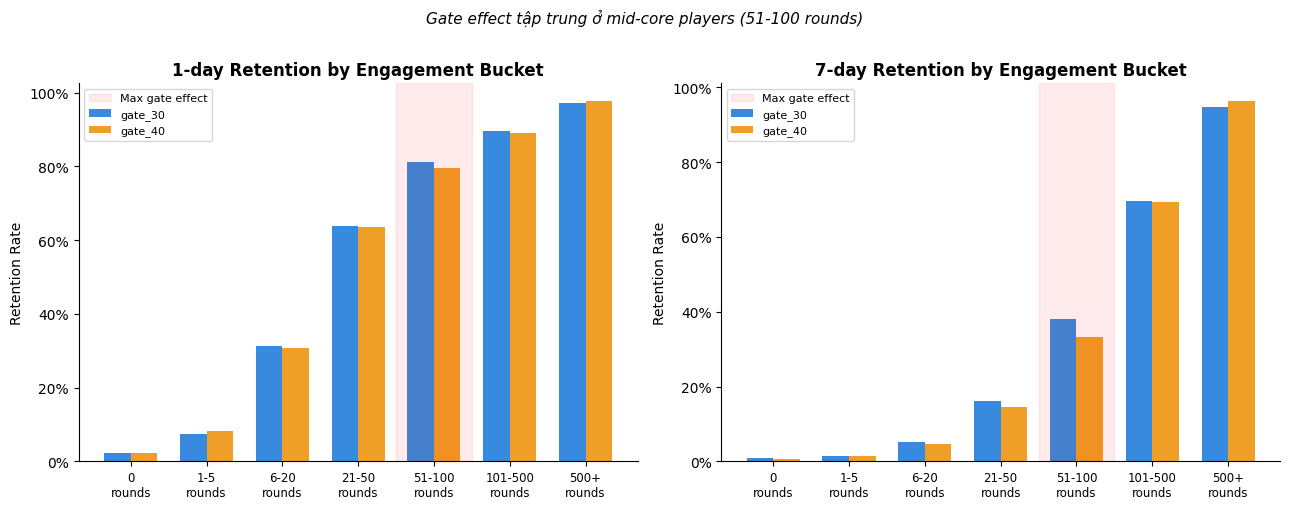

✓ Đã lưu app/ab_counts.csv

version     outcome     n  successes  failures     rate
gate_30 retention_1 44700      20034     24666 0.448188
gate_40 retention_1 45489      20119     25370 0.442283
gate_30 retention_7 44700       8502     36198 0.190201
gate_40 retention_7 45489       8279     37210 0.182000


In [11]:
#Retention by engagement bucket
df['rounds_bucket'] = pd.cut(df['sum_gamerounds'],
    bins=[-1, 0, 5, 20, 50, 100, 500, 99999],
    labels=['0', '1-5', '6-20', '21-50', '51-100', '101-500', '500+'])

bucket = (df.groupby(['rounds_bucket','version'], observed=True)
            [['retention_1','retention_7']]
            .mean()
            .round(4)
            .unstack('version'))

print("=== Retention rate by engagement bucket ===")
print(bucket.to_string())

print("\n=== Diff (gate_40 - gate_30) by bucket ===")
for outcome in ['retention_1', 'retention_7']:
    print(f"\n{outcome}:")
    for bucket_label in ['0', '1-5', '6-20', '21-50', '51-100', '101-500', '500+']:
        try:
            r30 = bucket[outcome]['gate_30'].loc[bucket_label]
            r40 = bucket[outcome]['gate_40'].loc[bucket_label]
            diff = r40 - r30
            direction = '▲ gate_40' if diff > 0 else '▼ gate_30'
            print(f"  {bucket_label:>8}: {diff:+.4f}  {direction}")
        except:
            pass

#Visualize bucket analysis + export ab_counts.csv
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bucket_labels = ['0', '1-5', '6-20', '21-50', '51-100', '101-500', '500+']
x = np.arange(len(bucket_labels))
w = 0.35

for ax, outcome, title in zip(axes,
    ['retention_1', 'retention_7'],
    ['1-day Retention by Engagement Bucket',
     '7-day Retention by Engagement Bucket']):

    r30 = [bucket[outcome]['gate_30'].loc[b] for b in bucket_labels]
    r40 = [bucket[outcome]['gate_40'].loc[b] for b in bucket_labels]

    bars30 = ax.bar(x - w/2, r30, w, label='gate_30', color=COLORS['gate_30'])
    bars40 = ax.bar(x + w/2, r40, w, label='gate_40', color=COLORS['gate_40'])

    # Highlight bucket có gate effect lớn nhất
    ax.axvspan(4 - 0.5, 4 + 0.5, alpha=0.08, color='red', label='Max gate effect')

    ax.set_xticks(x)
    ax.set_xticklabels([f'{b}\nrounds' for b in bucket_labels], fontsize=8.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Retention Rate')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)

plt.suptitle('Gate effect tập trung ở mid-core players (51-100 rounds)',
             fontsize=11, style='italic', y=1.01)
plt.tight_layout()
plt.savefig('../reports/retention_by_engagement_bucket.png', dpi=120, bbox_inches='tight')
plt.show()

# Export ab_counts cho notebook 02
def ab_counts(data, outcome_col):
    rows = []
    for v in ['gate_30', 'gate_40']:
        sub = data[data['version'] == v]
        successes = int(sub[outcome_col].sum())
        n = len(sub)
        rows.append({'version': v, 'outcome': outcome_col,
                     'n': n, 'successes': successes,
                     'failures': n - successes, 'rate': successes / n})
    return pd.DataFrame(rows)

ab_summary = pd.concat([ab_counts(df, 'retention_1'),
                        ab_counts(df, 'retention_7')], ignore_index=True)

import os
os.makedirs('../app', exist_ok=True)
ab_summary.to_csv('../app/ab_counts.csv', index=False)
print("✓ Đã lưu app/ab_counts.csv\n")
print(ab_summary.to_string(index=False))